# Repair Results Analysis

This notebook loads repair results from SQLite databases and generates summary statistics and visualizations.


In [14]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
%matplotlib inline

In [16]:
database_version = "16"

In [17]:
target_db = f'targets{database_version}.db'

In [18]:
sources_dbs = [
            "repair_results_openai_gpt-5-mini-2025-08-07_targets16.db",
            "repair_results_openai_gpt-4.1-2025-04-14_targets16.db",
            "repair_results_ollama_llama3:70b_targets16.db"
            ]

In [19]:
import sqlite3
conn = sqlite3.connect(target_db)
# Note: cases.id in targets DB corresponds to source puzzle.id
df_cases = pd.read_sql(
    "SELECT id AS puzzle_id, num_nonterminals, nonterminal_prob, loop_prob, mutation_depth, original_parser, corrupted_grammar FROM cases",
    conn
)

# Compute derived columns for analysis
df_cases['parser_size'] = df_cases['original_parser'].str.len()
df_cases['corrupted_symbol_count'] = df_cases['corrupted_grammar'].str.split().str.len()

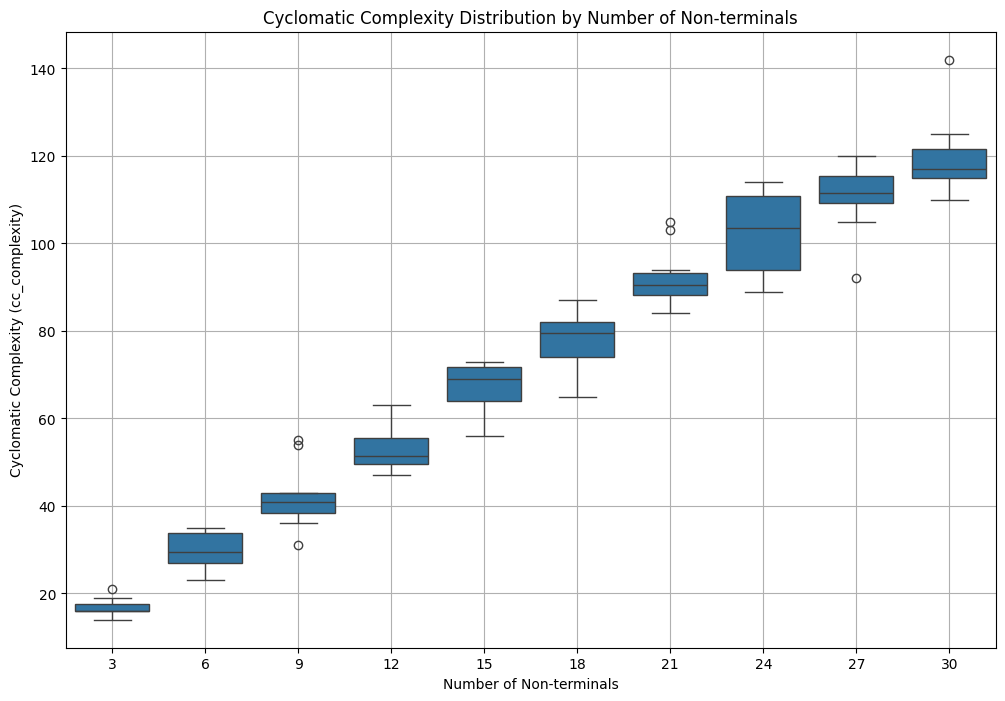

In [20]:
db_file = f'targets{database_version}.db'
conn = sqlite3.connect(db_file)

# Query the data
query = "SELECT num_nonterminals, cc_complexity FROM cases WHERE cc_complexity IS NOT NULL"
df = pd.read_sql_query(query, conn)

# Close the connection
conn.close()

# Create the plot
plt.figure(figsize=(12, 8))
sns.boxplot(x='num_nonterminals', y='cc_complexity', data=df)

# Set titles and labels
plt.title('Cyclomatic Complexity Distribution by Number of Non-terminals')
plt.xlabel('Number of Non-terminals')
plt.ylabel('Cyclomatic Complexity (cc_complexity)')
plt.grid(True)
plt.show()

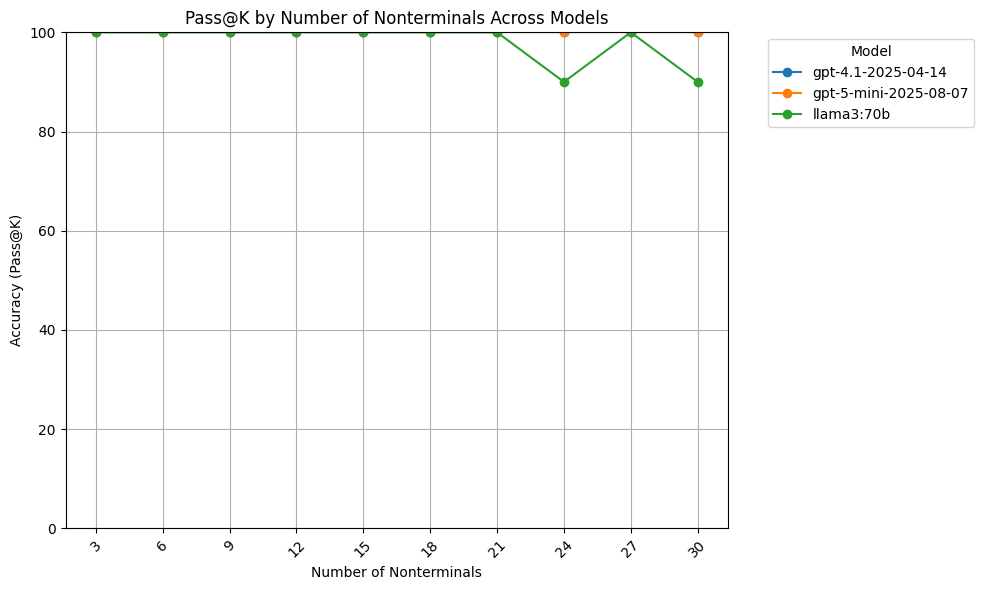

In [26]:
import matplotlib.pyplot as plt

# Preprocessing: ensure num_nonterminals is integer and clean data
df_cases['num_nonterminals'] = pd.to_numeric(df_cases['num_nonterminals'], errors='coerce')
df_cases = df_cases.dropna(subset=['num_nonterminals'])
df_cases['num_nonterminals'] = df_cases['num_nonterminals'].astype(int)

all_num_nts = sorted(df_cases['num_nonterminals'].unique())

# Mapping from puzzle_id to num_nonterminals
case_nt = df_cases[['puzzle_id', 'num_nonterminals']].rename(columns={'puzzle_id': 'case_id'})

records = []
models = []

# Pre-calculate denominator for each number of nonterminals (total unique puzzles)
denom = df_cases.groupby('num_nonterminals')['puzzle_id'].nunique()

for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_') \
             .removesuffix(f'_targets{database_version}.db').split('_')[1]
    models.append(model)

    with sqlite3.connect(db_path) as conn:
        df_res = pd.read_sql('SELECT case_id, correct FROM repair_results', conn)

    # For pass@K: each puzzle counts as passed if it succeeded at least once
    passed_by_case = (df_res.groupby('case_id')['correct'].max() > 0).rename('passed').reset_index()
    df_join = passed_by_case.merge(case_nt, on='case_id', how='left')

    # Numerator: number of unique puzzles passed for each num_nonterminals
    num_passed = df_join.groupby('num_nonterminals')['passed'].sum()

    pass_rate = (num_passed / denom * 100).reindex(all_num_nts, fill_value=0)

    for num_nt, rate in pass_rate.items():
        records.append({'model': model, 'num_nonterminals': num_nt, 'pass_at_k': rate})

df_nt_passk = pd.DataFrame(records)

# Plotting
plt.figure(figsize=(10, 6))
for model in sorted(set(models)):
    df_model = df_nt_passk[df_nt_passk['model'] == model].sort_values('num_nonterminals')
    plt.plot(df_model['num_nonterminals'], df_model['pass_at_k'], marker='o', label=model)

plt.xlabel('Number of Nonterminals')
plt.ylabel('Accuracy (Pass@K)')
plt.title('Pass@K by Number of Nonterminals Across Models')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(all_num_nts, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.ylim(0, 100)
plt.show()

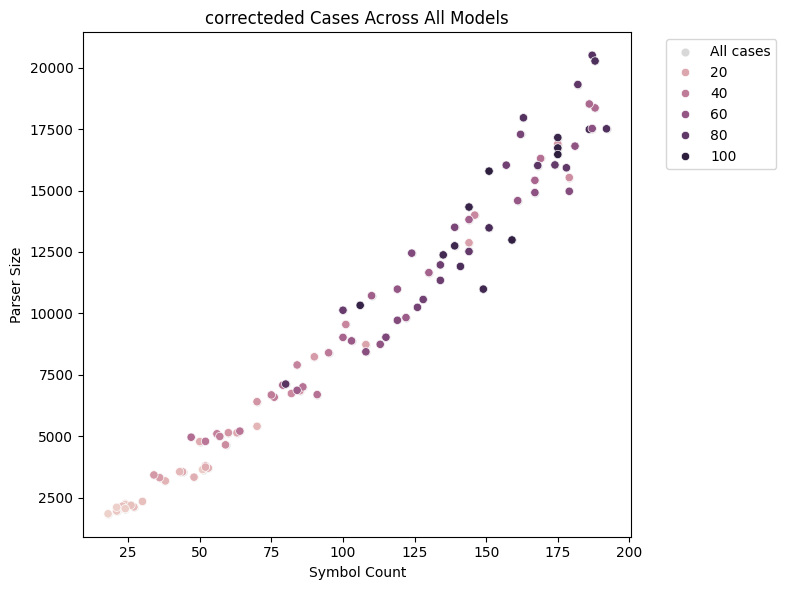

In [22]:
# Combined scatter plot of correcteded cases across all models
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_') \
             .removesuffix(f'_targets{database_version}.db').split('_')[1]
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, puzzle_id, correct, total_tokens, completion_tokens FROM repair_results', conn)
    # Merge using cases.id (puzzle_id) mapping to source puzzle.id
    df_tmp = df_res[df_res['correct'] == 1].merge(df_cases, left_on='case_id', right_on='puzzle_id')
    df_tmp['model'] = model
    records.append(df_tmp)
    conn.close()

df_correcteded_all = pd.concat(records, ignore_index=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', color='gray', alpha=0.3, label='All cases')
sns.scatterplot(data=df_correcteded_all, x='corrupted_symbol_count', y='parser_size', hue='puzzle_id_x')
plt.xlabel('Symbol Count')
plt.ylabel('Parser Size')
plt.title('correcteded Cases Across All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


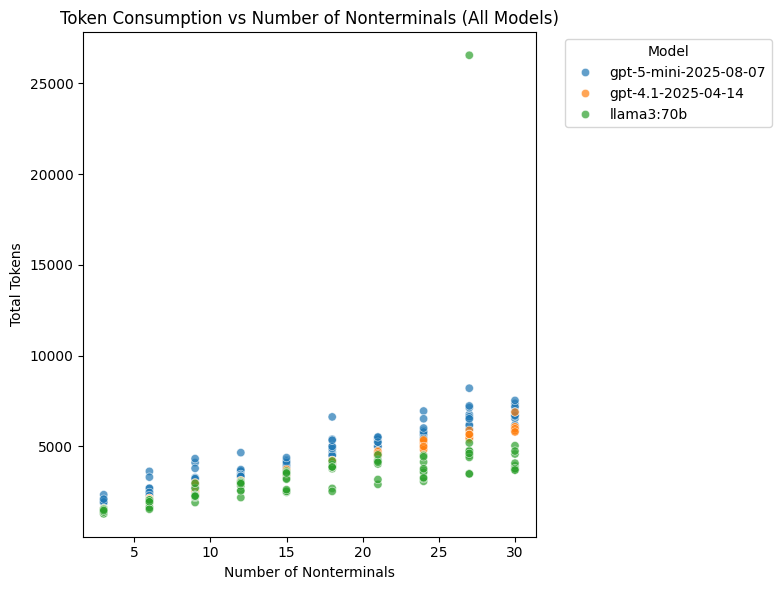

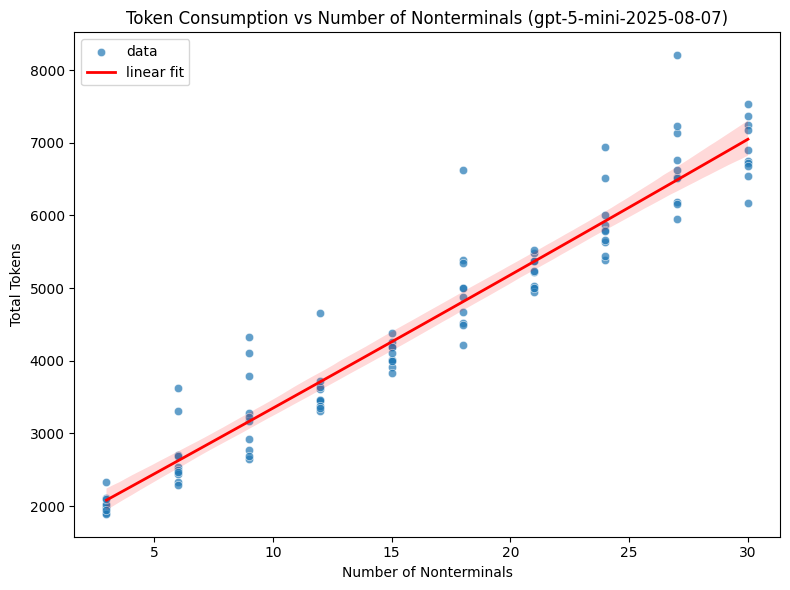

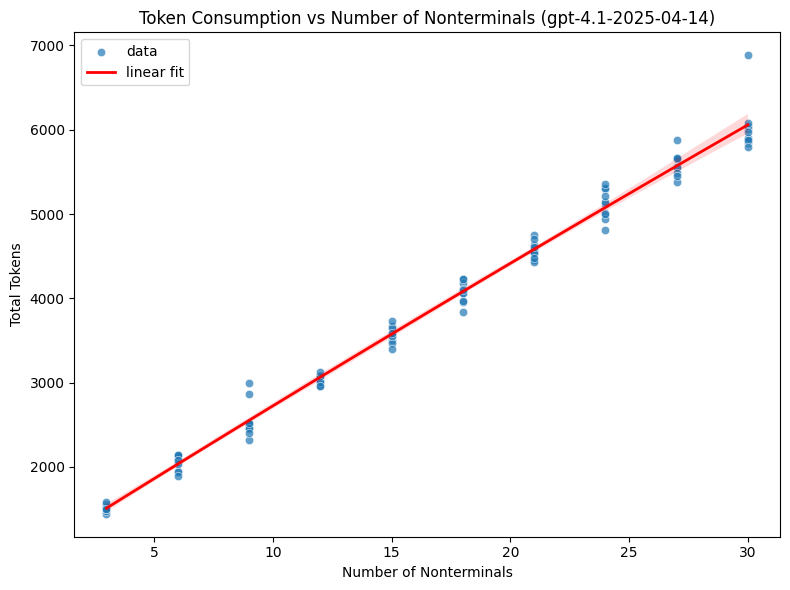

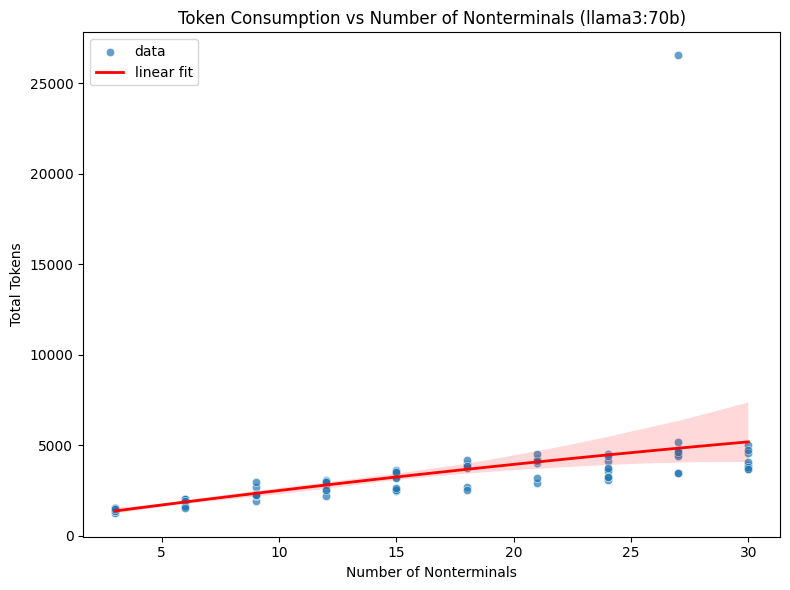

In [23]:
# Scatter plot of token consumption vs number of nonterminals across all correcteded cases
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_correcteded_all, x='num_nonterminals', y='total_tokens', hue='model', alpha=0.7)
plt.xlabel('Number of Nonterminals')
plt.ylabel('Total Tokens')
plt.title('Token Consumption vs Number of Nonterminals (All Models)')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Individual model plots with linear fit
for model in df_correcteded_all['model'].unique():
    df_mod = df_correcteded_all[df_correcteded_all['model'] == model]
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df_mod,
        x='num_nonterminals',
        y='total_tokens',
        color='C0',
        alpha=0.7,
        label='data'
    )
    sns.regplot(
        data=df_mod,
        x='num_nonterminals',
        y='total_tokens',
        scatter=False,      
        line_kws={'color': 'red', 'lw': 2},
        label='linear fit',
        order=2
    )

    plt.xlabel('Number of Nonterminals')
    plt.ylabel('Total Tokens')
    plt.title(f'Token Consumption vs Number of Nonterminals ({model})')
    plt.legend()
    plt.tight_layout()
    plt.show()


Pass@K

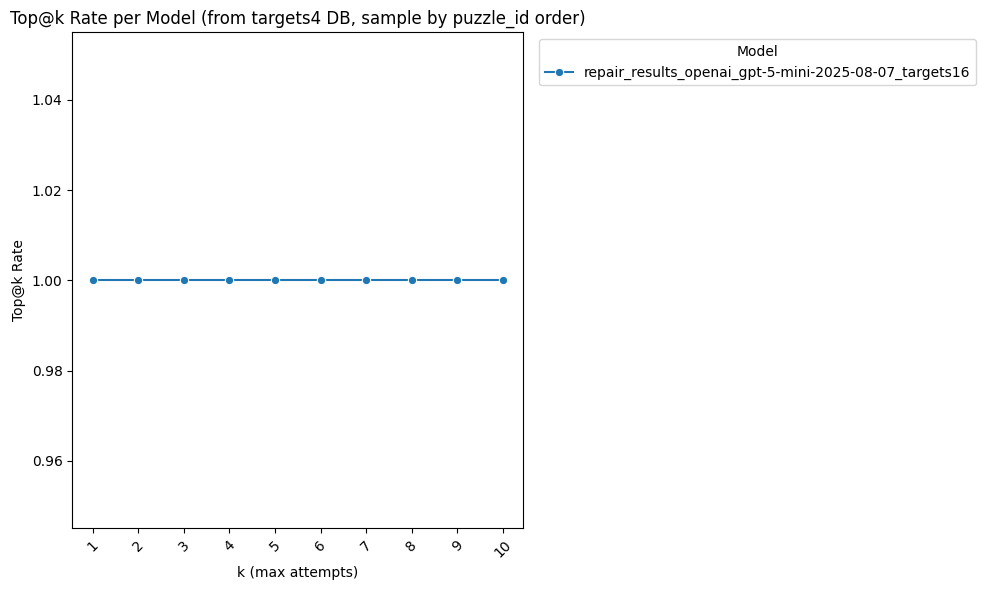

In [24]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

db_paths = [
    "repair_results_openai_gpt-5-mini-2025-08-07_targets16.db"
]
ks = list(range(1, 11))
records = []

for db_path in db_paths:
    model = os.path.splitext(os.path.basename(db_path))[0]
    conn = sqlite3.connect(db_path)

    # Skip if there's no repair_results table
    existing = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table' AND name='repair_results'",
        conn
    )
    if existing.empty:
        print(f"{db_path} has no repair_results table, skipping…")
        conn.close()
        continue

    # Check if 'sample' column exists
    info = pd.read_sql("PRAGMA table_info(repair_results)", conn)
    has_sample = 'sample' in info['name'].tolist()

    # Read required columns
    cols = "puzzle_id, correct" + (", sample" if has_sample else "")
    df = pd.read_sql(f"SELECT {cols} FROM repair_results", conn)
    conn.close()

    # If no sample column, assign sample numbers by puzzle_id occurrence order
    if not has_sample:
        df['sample'] = df.groupby('puzzle_id').cumcount() + 1

    total = df['puzzle_id'].nunique()
    for k in ks:
        df_k = df[df['sample'] <= k]
        # For each puzzle_id, if any of the first k attempts correcteded it, count as passed
        passed = df_k.groupby('puzzle_id')['correct'].max().sum()
        rate = passed / total
        records.append({"model": model, "k": k, "rate": rate})

df_pass_k = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pass_k, x='k', y='rate', hue='model', marker='o')
plt.xticks(ks, rotation=45)
plt.xlabel('k (max attempts)')
plt.ylabel('Top@k Rate')
plt.title('Top@k Rate per Model (from targets4 DB, sample by puzzle_id order)')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

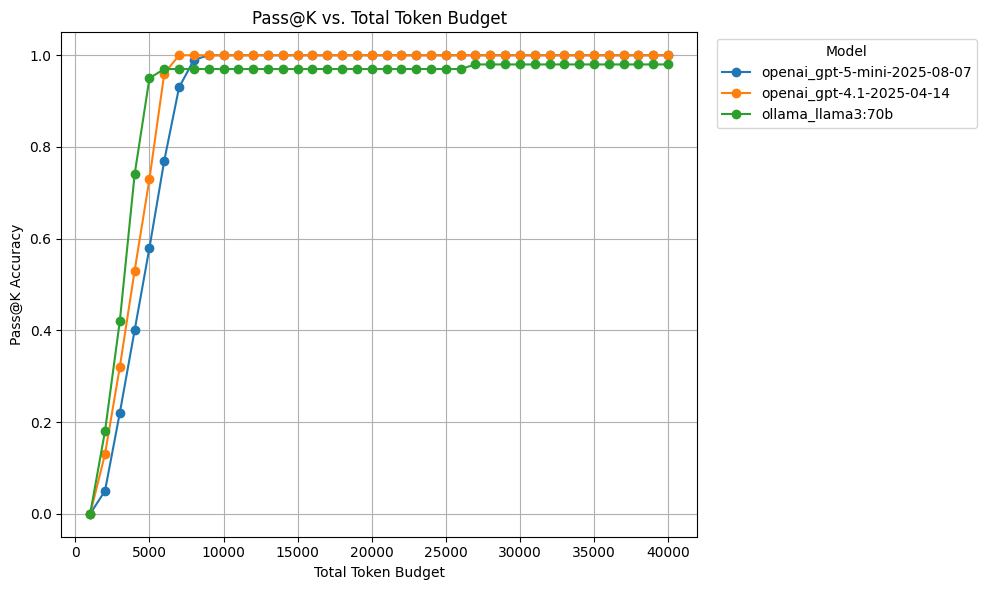

In [25]:
# token pass@K
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Point to your three result DBs:
sources_dbs = [
            "repair_results_openai_gpt-5-mini-2025-08-07_targets16.db",
            "repair_results_openai_gpt-4.1-2025-04-14_targets16.db",
            "repair_results_ollama_llama3:70b_targets16.db"
]

# 2. Define the budgets you want to sweep over (1 000 to 20 000 tokens):
budgets = list(range(1000, 40001, 1000))

# 3. Gather pass‐rates per (model, budget):
records = []
for db_path in sources_dbs:
    # Extract a short model name:
    base  = os.path.basename(db_path)
    model = base.split('repair_results_')[1].split('_targets')[0]
    
    # Load the attempts:
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql(
            "SELECT case_id, correct, total_tokens FROM repair_results",
            conn
        )
    total_puzzles = df['case_id'].nunique()
    
    # For each budget, check which puzzles succeed within that token limit:
    for b in budgets:
        df_b = df[(df['total_tokens'] <= b) & (df['correct'] == 1)]
        passed = df_b['case_id'].nunique()
        records.append({
            'model': model,
            'token_budget': b,
            'accuracy': passed / total_puzzles
        })

df_budget = pd.DataFrame(records)

# 4. Plot:
plt.figure(figsize=(10, 6))
for model in df_budget['model'].unique():
    sub = df_budget[df_budget['model'] == model]
    plt.plot(sub['token_budget'], sub['accuracy'], marker='o', label=model)

plt.xlabel('Total Token Budget')
plt.ylabel('Pass@K Accuracy')
plt.title('Pass@K vs. Total Token Budget')
plt.grid(True)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()